This notebook focuses on understanding, cleaning, transforming, and engineering features from the UCI Bank Marketing dataset to prepare it for predictive modeling.


**Task 1: Identifying the Prediction Target**


As stated in the assignment description, the business objective of the telemarketing campaign is to determine whether a contacted client subscribes to a term deposit. In the dataset, this outcome is represented by the variable y, which takes the values "yes" or "no". Therefore, y will be treated as the target variable in this analysis.

From a machine learning perspective, this problem falls under the category of classification, since the objective is to assign each client to one of two predefined classes: subscription ("yes") or no subscription ("no").



Although many other variables may superficially appear to be potential targets, they do not align with the business objective of the campaign. For example, variables such as loan, housing, or default describe the client’s financial status rather than the outcome of the marketing campaign. Predicting these variables would correspond to solving a different business problem.

Similarly, poutcome (the outcome of a previous campaign) contains relevant historical information and may be useful as a predictor, but it does not represent the outcome of the current marketing campaign. Therefore, it does not align with the stated business objective and should not be treated as the target variable either.


**Task 2: Data Loading and Exploration**

In [1]:
import pandas as pd
df_raw = pd.read_csv("data/bank-additional.csv", sep=";")
df = df_raw.copy()

In [2]:
df.shape

(4119, 21)

The dataset was loaded into a pandas DataFrame. Using df.shape, we observe that the dataset contains 4,119 observations and 21 variables, including the target variable y.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   str    
 2   marital         4119 non-null   str    
 3   education       4119 non-null   str    
 4   default         4119 non-null   str    
 5   housing         4119 non-null   str    
 6   loan            4119 non-null   str    
 7   contact         4119 non-null   str    
 8   month           4119 non-null   str    
 9   day_of_week     4119 non-null   str    
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   str    
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  cons.conf.idx   4119 non-null   float64
 18 

Based on the output of df.info(), the dataset contains 10 numerical variables (five stored as int64 and five as float64) and 11 categorical variables stored as object (string) type.

The numerical variables include demographic attributes such as age, campaign-related variables such as duration, campaign, pdays, and previous, as well as macroeconomic indicators including emp.var.rate, cons.conf.idx, euribor3m, and nr.employed.

The categorical variables include demographic characteristics such as job, marital, and education, financial attributes such as default, housing, and loan, campaign descriptors such as contact, month, day_of_week, and poutcome, as well as the target variable y.

All variables report 4,119 non-null values, indicating that there are no explicitly missing values in the dataset. However, some categorical variables may contain entries such as "unknown", which could represent implicit missing values. We will investigate this later.

In [4]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000
mean,40.113620,256.788055,2.537266,960.422190,0.190337,0.084972,93.579704,-40.499102,3.621356,5166.481695
std,10.313362,254.703736,2.568159,191.922786,0.541788,1.563114,0.579349,4.594578,1.733591,73.667904
min,18.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.635000,4963.600000
25%,32.000000,103.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.334000,5099.100000
50%,38.000000,181.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,317.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,88.000000,3643.000000,35.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


The basic summary statistics for the numerical variables were obtained using df.describe(). These statistics provide information about the central tendency and dispersion of the variables (mean, standard deviation, min, max…)

For example, the average client age is approximately 40 years, with values ranging from 18 to 88. The variable duration shows a wide range and a relatively high standard deviation which indicates high variability in call length.

Campaign-related variables like campaign and previous are highly skewed, as most clients were contacted only a few times. Moreover, the variable pdays frequently takes the value 999, which likely represents a special category rather than an actual number of days.

One variable that requires special consideration is duration, which represents the length of the phone call. This information is only available after the call has ended and would not be known at the time of making a prediction. Therefore, including this variable in the model could introduce data leakage, because it contains information that would not be available in a real-world prediction scenario.

Also, macroeconomic variables such as euribor3m and nr.employed are measured on very different numerical scales. As a result, feature scaling may be necessary before training the model.

In [5]:
df.describe(include='string')

,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
count,4119,4119,4119,4119,4119,4119,4119,4119,4119,4119,4119
unique,12,4,8,3,3,3,2,10,5,3,2
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent,no
freq,1012,2509,1264,3315,2175,3349,2652,1378,860,3523,3668


The categorical summary statistics obtained using df.describe(include='object') reveal several important patterns. Some variables, such as contact, look binary since they contain only two categories. Others, such as job, education, and month, contain multiple categories.

Although variables like default, housing, and loan conceptually represent binary attributes, they contain three categories. The additional category ("unknown") likely represents implicit missing values rather than a true third class.

Additionally, the variable poutcome is dominated by the category "nonexistent" which indicates that most clients were not contacted in a previous campaign.

Many categorical variables are highly imbalanced. For example, the majority of observations in default, housing, and loan correspond to the category "no". This imbalance may influence model performance and should be considered during preprocessing.

Class counts:
 y
no     3668
yes     451
Name: count, dtype: int64

Class fractions:
 y
no     0.8905
yes    0.1095
Name: proportion, dtype: float64


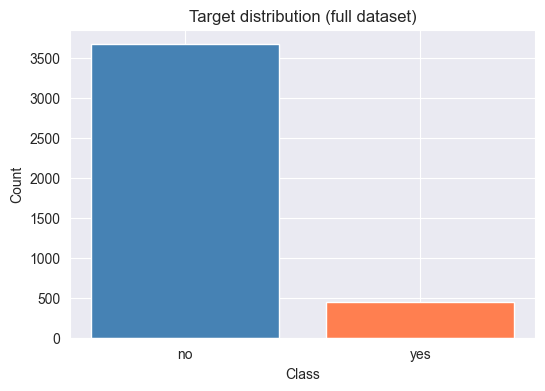


Imbalance ratio (minority/majority): 0.1230


In [6]:
import matplotlib.pyplot as plt

# Class balance
class_counts = df["y"].value_counts()
class_fractions = df["y"].value_counts(normalize=True)

print("Class counts:\n", class_counts)
print("\nClass fractions:\n", class_fractions.round(4))

# Bar chart of class distribution
plt.figure(figsize=(6, 4))
plt.bar(class_counts.index, class_counts.values,color=["steelblue", "coral"])
plt.title("Target distribution (full dataset)")
plt.ylabel("Count")
plt.xlabel("Class")
plt.show()

# Quantify imbalance
imbalance_ratio = class_counts.min() / class_counts.max()
print(f"\nImbalance ratio (minority/majority): {imbalance_ratio:.4f}")

An important step in exploratory analysis is checking the distribution of the target variable y to determine whether it is balanced or if one class dominates the other. The distribution plot clearly shows that the dataset is imbalanced.

Out of 4,119 observations, 3,668 correspond to clients who did not subscribe ("no"), while only 451 correspond to clients who subscribed ("yes"). This represents approximately 89.05% of the data in the majority class and 10.95% in the minority class.

The imbalance ratio is approximately 0.123, indicating that the minority class is strongly underrepresented. This may affect model performance. Therefore, when splitting the data into training, validation and test sets, we will use stratified sampling to preserve the original class distribution in all subsets.

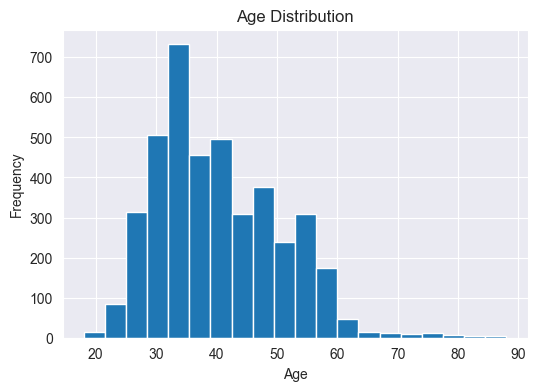

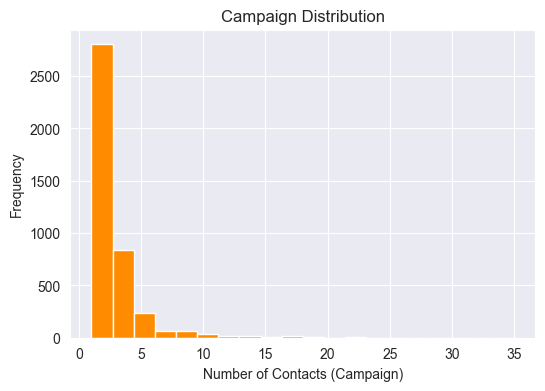

In [7]:
import matplotlib.pyplot as plt

# Age distribution
plt.figure(figsize=(6, 4))
plt.hist(df["age"], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

# Campaign distribution
plt.figure(figsize=(6, 4))
plt.hist(df["campaign"], bins=20, color="darkorange")
plt.title("Campaign Distribution")
plt.xlabel("Number of Contacts (Campaign)")
plt.ylabel("Frequency")
plt.show()

The distribution of age appears to be centered around middle adulthood, with most clients between approximately 30 and 50 years old. The distribution is slightly right-skewed, as there are fewer older clients above 60.

In contrast, the variable campaign is strongly right-skewed. Most clients were contacted only a small number of times, while a few clients were contacted many times. This suggests the presence of extreme values, which may require careful consideration during modeling.

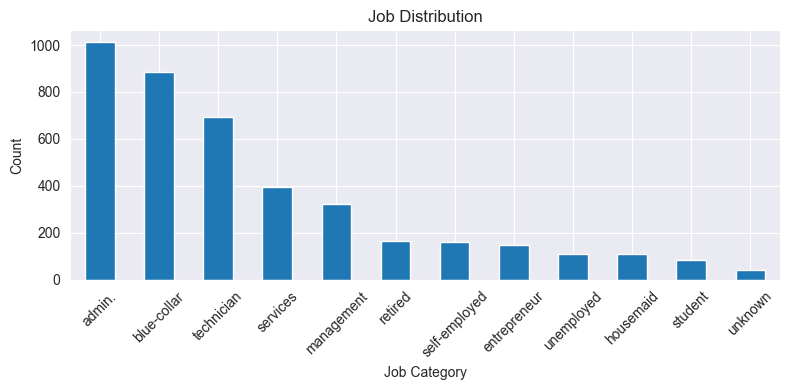

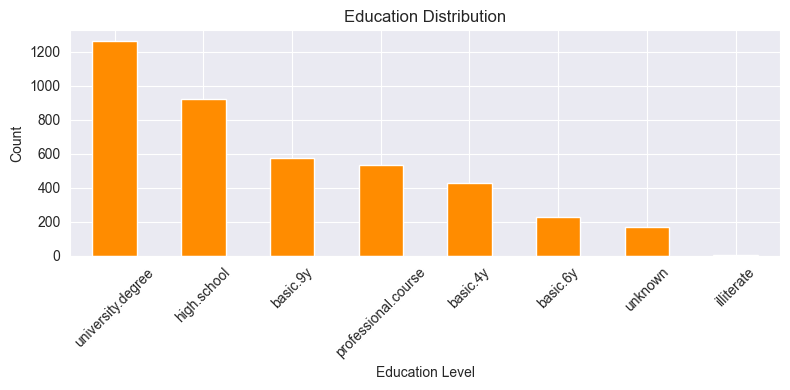

In [8]:
import matplotlib.pyplot as plt

# Job distribution
plt.figure(figsize=(8, 4))
df["job"].value_counts().plot(kind="bar")
plt.title("Job Distribution")
plt.xlabel("Job Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Education distribution
plt.figure(figsize=(8, 4))
df["education"].value_counts().plot(kind="bar", color="darkorange")
plt.title("Education Distribution")
plt.xlabel("Education Level")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The job distribution shows that the dataset is dominated by a few occupations, particularly admin. and blue-collar, while other categories such as student and unknown are much less represented. This indicates an uneven distribution across occupational groups.

Similarly, the education distribution indicates that most clients have either a university degree or a high school education, whereas categories such as illiterate are very rare.

In both variables, there is a category labeled "unknown", which represents implicit missing values rather than a meaningful additional group.

Overall, both variables have imbalanced category distributions, which may influence the modeling process, particularly because rare categories result in sparse dummy variables and may lead to less stable coefficient estimates.

**Task 3: Task Ordering**

The order in which data preparation steps are performed is critical to ensure a valid and unbiased evaluation of the model. In supervised learning, any step that learns information from the data must be performed using only the training set after the dataset has been split. Otherwise, information from the test set may leak into the training process, leading to overly optimistic performance estimates.

The correct sequence for this assignment is the following:

**- 1. Target Identification**

The dataset is first loaded, and the prediction target is identified based on the business objective. In this case, the variable y, indicating whether a client subscribes to a term deposit, is selected as the target.

At this stage, the full dataset may be inspected because no statistical relationships are being estimated and no model parameters are being learned. So, there is no risk of statistical data leakage.

**- 2. Exploratory Data Analysis**

Exploratory data analysis is conducted to understand the structure and characteristics of the dataset. During this stage, it is also important to assess potential data leakage risks. In supervised learning, leakage can arise from target leakage, proxy features, or temporal leakage.

In this dataset, the primary concern is temporal leakage related to the variable duration, which represents the length of the phone call and is only known after the call has ended. Since the objective is to predict subscription at the time of contact, including this variable would introduce future information into the model. Therefore, duration must be removed before proceeding to data splitting and model training to ensure a realistic evaluation.

**- 3. Data Splitting**

The dataset is then split into training, validation, and test sets using stratification to preserve the class distribution of the target variable. The training set is used to fit preprocessing steps and model parameters. The validation set is used for model tuning and comparison, while the test set is reserved exclusively for the final evaluation. From this stage forward, the test set must remain completely unseen until the final performance assessment.

The split must occur before any preprocessing step that estimates parameters from the data. If splitting were performed later, information leakage through preprocessing could occur, since the training process would indirectly use information from the validation or test sets. This would lead to overly optimistic evaluation results.

Moreover, when splitting the data, it is important to consider potential group leakage. This can occur when multiple observations correspond to the same entity, such as the same client, and related observations appear across different subsets. In this dataset, each row represents an individual campaign contact and no explicit grouping variable is provided, so standard splitting is appropriate and group leakage is unlikely to be an issue.

**- 4. Preprocessing After Data Splitting**

After splitting the data into training, validation, and test sets, any preprocessing step that learns something from the data must be done using only the training set.

The tasks inside this section include:

**-- 4.1 Handling Missing Values**

This step involves addressing both explicit and implicit missing values. Although no explicit missing values are present, implicit missingness was identified during exploration. We can use different strategies at this stage, such as imputation or treating missing values as a separate category. If imputation is applied, the imputation statistics must be computed using only the training set and then applied to the validation and test sets. Otherwise, information from the validation or test data would influence the training process, leading to preprocessing leakage.

**-- 4.2 Encoding Categorical Variables**

After handling missing values and special codes, categorical variables must be transformed into a numeric format, for example using one-hot encoding. It is important to address missingness first to ensure that the categorical values are consistent before being encoded.
The encoder must be fitted only on the training set and then applied to the validation and test sets. If we were to fit the encoder on the full dataset, we would be using information from the validation or test data during training. This would influence the feature representation and result in information leakage.

**-- 4.3 Feature Scaling**

After encoding the categorical variables, we scale the numerical variables if required. Scaling is performed at this stage because subsequent steps, such as distance-based resampling methods, rely on meaningful feature scales. If features are not scaled, variables with larger numeric ranges could dominate distance calculations.

If scaling is needed, for example through standardization or normalization, the scaling parameters must be computed using only the training set and then applied to the validation and test sets. Otherwise, the training data would be scaled using statistics from the validation or test data, and again, would introduce information leakage through preprocessing and result in an overly optimistic model evaluation.

**-- 4.4 Addressing Class Imbalance**

After scaling, we address the class imbalance issue. This step is performed after scaling because more advanced resampling techniques such as SMOTE or ADASYN are distance-based methods and generate synthetic observations using nearest-neighbor calculations in the feature space. Proper scaling ensures that these distance computations are meaningful and not dominated by features with larger numeric ranges.

Resampling must be applied only to the training set. If it were performed before splitting the data, duplicated or artificially generated observations could end up in both the training and test sets. This would violate the independence of the test set and it would inflate our performance estimates.

**--4.5 Feature Selection**

After all the previous steps, we can perform feature selection. This step is done at this stage so that selection is based on the final representation of the training data.

Any feature selection method that relies on data-driven criteria, such as correlations or statistical tests, must be carried out using only the training set. If feature selection were performed on the full dataset before splitting, the test set would influence which features are retained. This would result in information leakage and overly optimistic evaluation results.


**After all these steps, we can proceed to train the model on the training data and then use validation and test (only once) sets to evaluate it.**


An example of incorrect ordering would be performing preprocessing steps such as scaling, feature selection, or resampling before splitting the dataset into training, validation, and test sets. For instance, if feature selection was conducted on the entire dataset before splitting, the correlation structure of the validation or test sets would influence which features are retained. Similarly, if SMOTE were applied before splitting, synthetic observations could appear in both the training and test sets. In both cases, the model would indirectly incorporate information from data that is supposed to remain unseen. This would compromise the independence of the test set and give the false impression that the model generalizes better than it actually does.



**Task 4: Data Splitting**

In [9]:
from sklearn.model_selection import train_test_split

# Drop target and variable duration (temporal leakage)
X = df.drop(columns=["y", "duration"])
y = df["y"]

# Split into train (60%), validation (20%) and test(20%)

# 1) First split: Train and temporary (train = 60%, temp = 40%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.40,
    random_state=42,
    stratify=y,
)

# 2) Second split: split temporary into test (50%) and validation (50%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

df = pd.DataFrame({
"Set": ["Train", "Validation", "Test"],
"X shape": [X_train.shape, X_val.shape, X_test.shape],
"y shape": [y_train.shape, y_val.shape, y_test.shape],
})
display(df.style.hide(axis="index"))

Set,X shape,y shape
Train,"(2471, 19)","(2471,)"
Validation,"(824, 19)","(824,)"
Test,"(824, 19)","(824,)"


The dataset was split into 60% training, 20% validation, and 20% test sets. This choice was made following the guideline that validation and test sets must be large enough to provide reliable evaluation statistics. In this dataset, the minority class (“yes”) contains 451 observations. Allocating 20% to both validation and test results in approximately 90 minority examples in each set. This is well above the minimum guideline of around 12 observations per class and close to the commonly suggested threshold of 100 per class for reliable evaluation. At the same time, the training set retains approximately 270 minority examples, which is enough for training a shallow model such as logistic regression, since such models generally require less data than more complex models.

Stratified splitting was performed with respect to the target variable y. As discussed earlier, the dataset is clearly imbalanced. Without stratification, random splitting could result in validation or test sets containing too few positive examples, which would lead to unstable and potentially misleading evaluation metrics. Stratification ensures that each subset preserves the original class distribution.

The split was performed after exploratory analysis but before any preprocessing steps that estimate parameters from the data. Splitting must occur at this stage to ensure that the validation and test sets remain independent. If splitting were performed later, preprocessing statistics could be influenced by information from the validation or test sets, resulting in information leakage through preprocessing. This would lead to overly optimistic performance estimates and inflated evaluation results.

**Task 4: Handling Missing Values**

During exploratory data analysis, the dataset was inspected for missing values. No explicit missing values (NaN entries) were found, as all variables report complete non-null counts.

However, implicit missing values were identified in several categorical variables in the form of the category "unknown". In addition, a sentinel value was detected in the variable pdays, where the value 999 represents a special code and not an actual measurement.

In [10]:
cat_cols = df_raw.select_dtypes(include=["object", "string"]).columns

# Quantify missingness
unknown_counts = (df_raw[cat_cols] == "unknown").sum().sort_values(ascending=False)
unknown_counts = unknown_counts[unknown_counts > 0]
unknown_pct = (unknown_counts / len(df_raw) * 100).round(2)

print("\nImplicit missing values encoded as 'unknown':")
print(pd.DataFrame({"unknown_count": unknown_counts, "unknown_pct": unknown_pct}))


Implicit missing values encoded as 'unknown':
           unknown_count  unknown_pct
default              803        19.50
education            167         4.05
housing              105         2.55
loan                 105         2.55
job                   39         0.95
marital               11         0.27


The highest proportion of "unknown" values is found in the variable default, where approximately 19.5% of observations fall into this category. This is a relatively large percentage compared to the other variables. The variable education contains around 4.05% "unknown" values, while housing and loan each have approximately 2.55%. The variables job and marital have very low proportions of missingness, below 1%. Overall, implicit missingness is concentrated mainly in the variable default.

For the categorical variables containing the category "unknown", observations will not be removed. Removing these rows would result in a substantial loss of data, particularly for the variable default.

From a data cleaning perspective, these values are not inconsistent or incorrect entries; they represent recorded but unavailable information. Therefore, no correction is required.

This is a modeling decision since missingness may carry predictive information. Because logistic regression can handle categorical variables through encoding, the category "unknown" will be retained as a separate category rather than being removed or imputed.

For consistency, the same strategy is applied to all categorical variables containing "unknown", regardless of the percentage of missingness. Although the extent of missingness varies across variables, treating them differently would introduce unnecessary complexity into the preprocessing pipeline. Therefore, it is preferred to follow a consistent approach that ensures transparency and allows the model to capture any potential signal associated with missingness.



In [11]:
pdays_999_count = (df_raw["pdays"] == 999).sum()
print("Number of 999 values in pdays:", pdays_999_count)

pdays_999_pct = round((df_raw["pdays"] == 999).mean() * 100, 2)
print("Percentage of 999 values in pdays:", pdays_999_pct, "%")

Number of 999 values in pdays: 3959
Percentage of 999 values in pdays: 96.12 %


The variable pdays contains a sentinel value 999 in 3,959 observations, which represents approximately 96.12% of the dataset. This indicates that the majority of clients were not previously contacted before the current campaign. In conclusion, the value 999 does not represent an actual number of days, but rather a structural code that indicates the absence of previous contact. Therefore, it should not be treated as a regular numeric value.

In [12]:
# Drop pdays
for dataset in [X_train, X_val, X_test]:
    dataset.drop(columns=["pdays"], inplace=True)

I decided to clean the data and exclude it from the final model to ensure better stability and performance. This extreme value acts as a significant outlier for Logistic Regression and can distort the relationship between features. Moreover, this variable is highly redundant with previous, as any value other than 999 in pdays already implies that previous is greater than zero. By removing pdays, I eliminate multicollinearity and prevent the model from being influenced by noisy, sparse data, while still retaining the essential historical contact information through the previous variable."

Since this adjustment is a structural modification and does not involve estimating any parameters from the data, it does not require fitting on the training set only. The elimination can be applied consistently to the training, validation, and test sets without introducing information leakage.

**Task 5: Encoding Categorical Variables**


In [13]:
cat_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()
cat_cols

['Set', 'X shape', 'y shape']

During exploratory data analysis, the categorical variables in the dataset were identified: job, marital, education, default, housing, loan, contact, month, day_of_week, and poutcome.

Among these variables, most are nominal, meaning their categories do not have a natural or meaningful order. The variables job, marital, default, housing, loan, contact, month, day_of_week, and poutcome represent different groups or types, but one category is not inherently higher or lower than another. For example, a job category is simply a type of occupation, and months or days of the week do not represent increasing or decreasing levels in this context.

The variable education, however, is considered ordinal because its categories reflect increasing levels of academic education. In this case, there is a logical order from lower to higher education levels.

In [14]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

# 1) Define categorical columns
cat_cols = [
    "job", "marital", "default", "housing", "loan",
    "contact", "month", "day_of_week", "poutcome",
    "education"
]

# Fit OneHotEncoder on training only
ohe = OneHotEncoder(
    handle_unknown="ignore",
    drop="first",
    sparse_output=False
)

ohe.fit(X_train[cat_cols])

# Transform train / val / test
X_train_cat = ohe.transform(X_train[cat_cols])
X_val_cat   = ohe.transform(X_val[cat_cols])
X_test_cat  = ohe.transform(X_test[cat_cols])

# 3) Wrap into DataFrames with feature names
cat_feature_names = ohe.get_feature_names_out(cat_cols)

X_train_cat = pd.DataFrame(X_train_cat, columns=cat_feature_names, index=X_train.index)
X_val_cat   = pd.DataFrame(X_val_cat,   columns=cat_feature_names, index=X_val.index)
X_test_cat  = pd.DataFrame(X_test_cat,  columns=cat_feature_names, index=X_test.index)

num_cols = [c for c in X_train.columns if c not in cat_cols]

X_train_num = X_train[num_cols].copy()
X_val_num   = X_val[num_cols].copy()
X_test_num  = X_test[num_cols].copy()

#Combine with the rest of numeric features
X_train_step = pd.concat([X_train_num, X_train_cat], axis=1)
X_val_step   = pd.concat([X_val_num,   X_val_cat], axis=1)
X_test_step  = pd.concat([X_test_num,  X_test_cat], axis=1)

print("Before encoding (train):", X_train.shape)
print("After encoding (train): ", X_train_step.shape)

Before encoding (train): (2471, 18)
After encoding (train):  (2471, 51)


*Code assistance generated with ChatGPT (OpenAI), using the prompt shown below (accessed on March 1, 2026).*
*“Generate scikit-learn code to one-hot encode only the nominal categorical variables (job, marital, default, housing, loan, contact, month, day_of_week, poutcome) using OneHotEncoder fitted on the training set only and applied to validation/test to avoid leakage. Keep the ordinal variable education unchanged for now, then concatenate the encoded columns back with the remaining features and print the dimensionality before/after. Thank you.”*

For the nominal categorical variables, one-hot encoding is used. Logistic regression is a linear model, which means it requires numerical inputs and it learns a separate coefficient for each feature. If nominal categories were encoded using arbitrary numbers (for example, job = 1, 2, 3), logistic regression would incorrectly treat those values as ordered and assume that differences between them have meaning. One-hot encoding avoids this by creating one binary column per category.

To keep the preprocessing consistent, the same one-hot encoding strategy is applied to all nominal variables. The encoder is fitted using only the training set and then applied to the validation and test sets. If it were fitted on the full dataset, the model would indirectly use information from the validation or test sets when constructing the feature space possibly introducing preprocessing leakage.

In [15]:
df_raw["education"].value_counts()

education
university.degree      1264
high.school             921
basic.9y                574
professional.course     535
basic.4y                429
basic.6y                228
unknown                 167
illiterate                1
Name: count, dtype: int64

Even though education is an ordinal variable, I decided to encode it using one-hot encoding rather than assigning integer values. This is because if we encoded it as 0, 1, 2, and so on, we would be assuming that the difference between consecutive levels has the same impact on the prediction, which may not be realistic. For example, the impact of moving from secondary education to a university degree could be stronger than the impact of moving from a lower to a mid-level qualification on the probability of subscribing to the term deposit.

Since we do not want to impose this equal-spacing assumption, we apply one-hot encoding instead, which allows logistic regression to learn a separate coefficient for each education level. As with the other categorical variables, the encoder is fitted only on the training set and then applied to the validation and test sets to prevent preprocessing leakage.

I wanted to point out that one category (“illiterate”) appears only once and may not be present in the training set. In principle, one-hot encoding with the m−1 rule (drop='first') would create one fewer column than the number of observed categories (that is, 8 instead of 9), in order to avoid multicollinearity. However, since the encoder is fitted only on the training data, it only creates columns for the categories actually observed during training. If one category is not present in the training set, it is not included in the encoded feature space. By using handle_unknown="ignore", the encoder safely handles such cases without introducing errors or leaking information from the validation or test sets.

One-hot encoding increases the dimensionality of the dataset since each variable expands into multiple binary features, reaching a total of 53 features. However, this is not a problem in this case, since the number of training observations remains much larger than the number of features, which is generally considered a safe setting for simple models such as logistic regression. Therefore, we are not at significant risk of overfitting due solely to the increase in dimensionality. Moreover, the use of L2 regularization in the logistic regression implementation provides an additional safety against this high-dimensional noise.

It also improves interpretability because each logistic regression coefficient can be read as the effect of a specific category relative to a baseline.

Since logistic regression is a linear model, it can only represent linear decision boundaries. One-hot encoding allows the model to assign separate coefficients to each category without imposing artificial numerical order. This ensures that the model captures the effect of each category independently, rather than interpreting category labels as meaningful numeric values with an order or distance that does not exist.

**Task 6: Feature Scaling**

In [16]:
numeric_cols = X_train_step.select_dtypes(include=["int64", "float64"]).columns
numeric_cols

Index(['age', 'campaign', 'previous', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'job_blue-collar',
       'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired',
       'job_self-employed', 'job_services', 'job_student', 'job_technician',
       'job_unemployed', 'job_unknown', 'marital_married', 'marital_single',
       'marital_unknown', 'default_unknown', 'default_yes', 'housing_unknown',
       'housing_yes', 'loan_unknown', 'loan_yes', 'contact_telephone',
       'month_aug', 'month_dec', 'month_jul', 'month_jun', 'month_mar',
       'month_may', 'month_nov', 'month_oct', 'month_sep', 'day_of_week_mon',
       'day_of_week_thu', 'day_of_week_tue', 'day_of_week_wed',
       'poutcome_nonexistent', 'poutcome_success', 'education_basic.6y',
       'education_basic.9y', 'education_high.school', 'education_illiterate',
       'education_professional.course', 'education_university.degree',
       'education_unknown'],
      dtype

After encoding the categorical variables, all features in the dataset are now numerical. However, not all numerical features require scaling. The binary variables created through one-hot encoding already take values of 0 and 1, so they are naturally on the same scale. In contrast, the original numerical variables such as age, campaign, pdays, previous, and the macroeconomic indicators are measured on very different ranges. Without scaling, variables with larger numeric ranges could dominate the learning process.

In [17]:
from sklearn.preprocessing import StandardScaler

# Numerical variables that require scaling
pure_numeric_cols = ['age', 'campaign', 'previous', 'emp.var.rate',
                     'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

scaler = StandardScaler()

# Fit scaler on training data only (avoid leakage)
scaler.fit(X_train_step[pure_numeric_cols])

# Apply the same transformation to train, validation, and test sets
X_train_step[pure_numeric_cols] = scaler.transform(X_train_step[pure_numeric_cols])
X_val_step[pure_numeric_cols]   = scaler.transform(X_val_step[pure_numeric_cols])
X_test_step[pure_numeric_cols]  = scaler.transform(X_test_step[pure_numeric_cols])

For this reason, we apply standardization using a StandardScaler. Logistic regression is a linear model optimized using gradient-based methods and scaling improves numerical stability and convergence during optimization. Standardization transforms each numerical feature to have mean zero and unit variance, ensuring that no variable disproportionately influences the optimization process due to its scale.

The scaler is fitted only on the training set and then applied to the validation and test sets. Fitting the scaler on the full dataset would incorporate information from the validation or test sets into the scaling parameters, which would result in preprocessing leakage.

Additionally, scaling affects the magnitude and comparability of the model coefficients. In logistic regression, regularization penalizes large coefficients. If features are on very different scales, variables with smaller numeric ranges may require larger coefficients to have the same impact, and would therefore be penalized more heavily. This would distort the learning process. By standardizing the numerical variables we make sure that regularization treats all features more fairly and that coefficient magnitudes better reflect their relative importance.

**Task 7: Addressing Class Imbalance**

In [18]:
train_counts = y_train.value_counts()
train_pct = y_train.value_counts(normalize=True) * 100

print("Training set class counts:\n", train_counts)
print("\nTraining set class percentages:\n", train_pct.round(2))

Training set class counts:
 y
no     2200
yes     271
Name: count, dtype: int64

Training set class percentages:
 y
no     89.03
yes    10.97
Name: proportion, dtype: float64


The class distribution in the training set is clearly imbalanced, with the majority class (“no”) representing approximately 89% of observations and the minority class (“yes”) representing around 11%. This imbalance is relevant for the prediction task because the model may become biased toward predicting the majority class, especially when using accuracy as the evaluation metric.

Since the objective of the model is to predict whether a client subscribes to a term deposit, correctly identifying the minority class (“yes”) is important. In imbalanced settings, a model can achieve high accuracy by simply predicting the majority class, while performing poorly in detecting positive cases.

In [19]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE only on training data
smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_step, y_train
)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_resampled.value_counts())

Before SMOTE: y
no     2200
yes     271
Name: count, dtype: int64
After SMOTE: y
no     2200
yes    2200
Name: count, dtype: int64


To address this issue, we apply SMOTE (Synthetic Minority Oversampling Technique). Unlike simple random oversampling, which just duplicates existing minority observations and may increase the risk of overfitting, SMOTE generates synthetic minority examples by interpolating between existing minority samples in the feature space. As discussed in class, this method increases the representation of the minority class while preserving variability in the data.

This assumption is reasonable in our case, since the features are numerical after encoding and scaling, and logistic regression operates in a linear feature space. By generating new minority observations between existing ones, SMOTE helps the model better define the minority region without simply duplicating the same points. This supports the learning process of a linear model and leads to a more balanced and stable decision boundary.

SMOTE is applied only to the training set, after scaling (since SMOTE is distance-based and relies on nearest-neighbor calculations) and before training the model. This ensures that the model learns from a balanced dataset without allowing information from the validation or test sets to influence the training process. If resampling were applied before splitting the dataset, synthetic or duplicated observations could appear in both the training and test sets. This would violate the independence of the test set and could lead to overly optimistic evaluation results, since the model would effectively be evaluated on data it has already seen or data that is very similar.

Class imbalance affects evaluation metrics because accuracy alone can be misleading. If the model simply predicts the majority class, it may achieve high accuracy while failing to correctly identify clients who actually subscribe. Therefore, accuracy does not provide a complete picture of performance in this setting.

For this reason, precision and recall are also considered. Precision reflects how reliable the model’s positive predictions are, while recall indicates how effectively the model detects the minority class. In imbalanced problems, there is typically a trade-off between the two. For this prediction task, correctly identifying subscribers is important, so recall for the minority class becomes particularly relevant.

**Task 8: Feature Selection**

In [20]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)

selector.fit(X_train_resampled)

kept_columns = X_train_resampled.columns[selector.get_support()]

X_train_resampled = X_train_resampled[kept_columns]
X_val_step = X_val_step[kept_columns]
X_test_step = X_test_step[kept_columns]

Features with very low variance were examined using a variance threshold. Features that show very little variability across observations contribute minimal information to the prediction task and may lead to instability in coefficient estimation. Since scaling was already applied, most meaningful numerical variables have variance close to 1. Therefore, a threshold of 0.01 was used to identify features whose variance is extremely small relative to standardized variables. Almost constant features do not help logistic regression learn patterns. Applying this threshold removes features that add little useful information without eliminating relevant predictors. However, in our case there is no feature with these characteristics.

In [21]:
threshold = 0.9
corr = X_train_step.corr().abs()

pairs = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if corr.iloc[i, j] > threshold:
            pairs.append((corr.columns[i], corr.columns[j], corr.iloc[i, j]))

pairs

[('emp.var.rate', 'euribor3m', np.float64(0.9700126574780241)),
 ('euribor3m', 'nr.employed', np.float64(0.9416986150840211)),
 ('housing_unknown', 'loan_unknown', np.float64(1.0))]

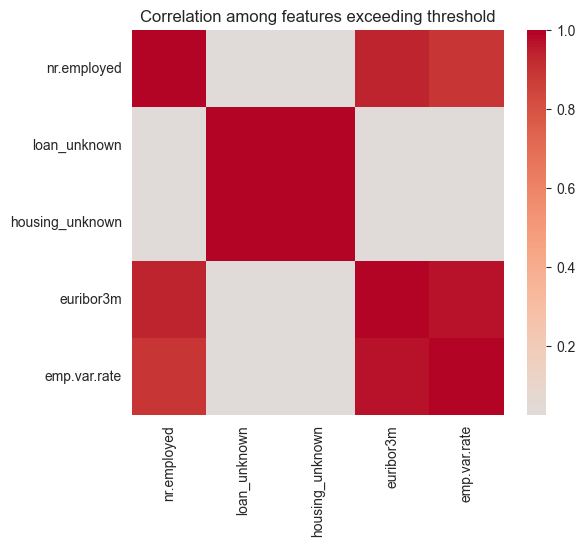

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

cols_to_plot = list(set([p[0] for p in pairs] + [p[1] for p in pairs]))

subset_corr = X_train_step[cols_to_plot].corr()

plt.figure(figsize=(6,5))
sns.heatmap(subset_corr, cmap="coolwarm", center=0)
plt.title("Correlation among features exceeding threshold")
plt.show()

In [23]:
cols_to_drop = ["housing_unknown", "emp.var.rate", "nr.employed"]

# Drop from training
X_train_resampled = X_train_resampled.drop(columns=cols_to_drop, errors="ignore")

# Drop from validation and test
X_val_step = X_val_step.drop(columns=cols_to_drop, errors="ignore")
X_test_step = X_test_step.drop(columns=cols_to_drop, errors="ignore")

To detect multicollinearity, the absolute correlation matrix was computed on the training set, and a threshold of 0.9 was used to identify highly correlated predictors. This threshold was chosen to capture near-linear dependence between features, which can lead to unstable coefficient estimates in logistic regression. We know that logistic regression is sensitive to multicollinearity, since it relies on estimating separate coefficients for each predictor. When two variables are highly correlated, the model struggles to distinguish their individual effects.

The correlation analysis revealed a strong positive relationship between emp.var.rate and euribor3m (≈0.97), as well as between euribor3m and nr.employed (≈0.94). These variables represent related macroeconomic indicators and, as a consequence, capture overlapping information. Moreover, housing_unknown and loan_unknown exhibit a perfect correlation of 1, meaning they contain identical information.

To improve model stability and interpretability, variables from each highly correlated group were removed. In particular, housing_unknown was eliminated to avoid perfect multicollinearity between the dummy variables. Among the macroeconomic indicators, emp.var.rate and nr.employed were removed, while euribor3m was retained, since it is a widely used interest rate indicator directly related to borrowing conditions. Doing this we are removing redundancy.

As mentioned earlier, duration was removed because it is not available at prediction time. This variable represents the length of the phone call, which is only known after the call has already happened. Since the goal is to predict whether a client will subscribe at the time of contact, keeping duration would introduce temporal data leakage and make the model look better than it would be in a real scenario.

Feature selection must be performed using the training set only because it relies on statistics computed from the data, such as variance or correlations between predictors. If these statistics are calculated using the entire dataset before splitting, information from the validation or test sets would influence which features are retained or removed. This means that the model would indirectly “see” part of the unseen data during preprocessing.

Performing feature selection before splitting would therefore introduce information leakage. Even though the target values are not directly used, the structure of the feature space would be shaped by patterns that are present in the validation or test sets. As a result, the selected features might be overly tailored to the full dataset, leading to biased model evaluation. The validation and test performance would appear better than it truly is.

**Task 9: Training a Logistic Regression Model**

In [24]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Define the positive class explicitly (minority class = "yes")
POS_LABEL = "yes"

# Zero Rule baseline:
dummy = DummyClassifier(strategy="most_frequent", random_state=42)

# Fit baseline model on the training data
dummy.fit(X_train_resampled, y_train_resampled)

# Generate predictions on the validation set
dummy_val_pred = dummy.predict(X_val_step)

# Compute evaluation metrics on validation set
dummy_accuracy = accuracy_score(y_val, dummy_val_pred)
dummy_precision = precision_score(y_val, dummy_val_pred, pos_label=POS_LABEL, zero_division=0)
dummy_recall = recall_score(y_val, dummy_val_pred, pos_label=POS_LABEL, zero_division=0)

print("Zero Rule — Validation")
print(f"Accuracy:  {dummy_accuracy:.4f}")
print(f"Precision: {dummy_precision:.4f}")
print(f"Recall:    {dummy_recall:.4f}")

Zero Rule — Validation
Accuracy:  0.8908
Precision: 0.0000
Recall:    0.0000


In [25]:
from sklearn.linear_model import LogisticRegression

# Initialize Logistic Regression model
lr = LogisticRegression(max_iter=1000, random_state=42)

# Train the model on the training data
lr.fit(X_train_resampled, y_train_resampled)

# Generate predictions on the validation set
val_pred = lr.predict(X_val_step)

# Compute evaluation metrics on validation set
val_accuracy = accuracy_score(y_val, val_pred)
val_precision = precision_score(y_val, val_pred, pos_label=POS_LABEL, zero_division=0)
val_recall = recall_score(y_val, val_pred, pos_label=POS_LABEL, zero_division=0)

print("\nLogistic Regression — Validation")
print(f"Accuracy:  {val_accuracy:.4f}")
print(f"Precision: {val_precision:.4f}")
print(f"Recall:    {val_recall:.4f}")


Logistic Regression — Validation
Accuracy:  0.8155
Precision: 0.3218
Recall:    0.6222


In [26]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Zero Rule", "Logistic Regression"],
    "Accuracy": [dummy_accuracy, val_accuracy],
    "Precision": [dummy_precision, val_precision],
    "Recall": [dummy_recall, val_recall]
})

comparison

,Model,Accuracy,Precision,Recall
0,Zero Rule,0.890777,0.000000,0.000000
1,Logistic Regression,0.815534,0.321839,0.622222


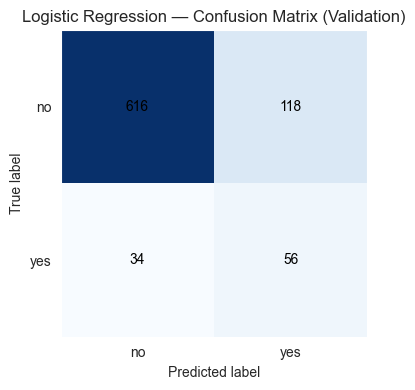

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

labels = ["no", "yes"]  # keep order consistent

cm = confusion_matrix(y_val, val_pred, labels=labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, values_format="d", cmap="Blues", colorbar=False)

# Remove grid lines so numbers are visible
ax.grid(False)

# Make numbers darker for visibility
for text in ax.texts:
    text.set_color("black")

ax.set_title("Logistic Regression — Confusion Matrix (Validation)")
plt.tight_layout()
plt.show()

The model achieved an accuracy of approximately 0.82, a precision of 0.32, and a recall of 0.62.

There are 90 actual subscribers in the validation set. The model correctly identifies 56 of them and misses 34. Detecting 56 out of 90 subscribers (recall ≈ 62%) is a meaningful result, especially considering that subscribers represent a clear minority of the dataset.

At the same time, the model predicts 174 clients as subscribers (56 correct and 118 incorrect). This results in a precision of about 32%, meaning that roughly one out of every three predicted subscribers actually subscribes. Although this is not extremely high, it is reasonable in the context of a highly imbalanced dataset, where subscribers represent a small proportion of the data. The model is clearly trying to identify the minority class rather than defaulting to predicting “no” for everyone, which naturally increases the number of false positives.

Overall, the model trades accuracy for detecting better the minority class.

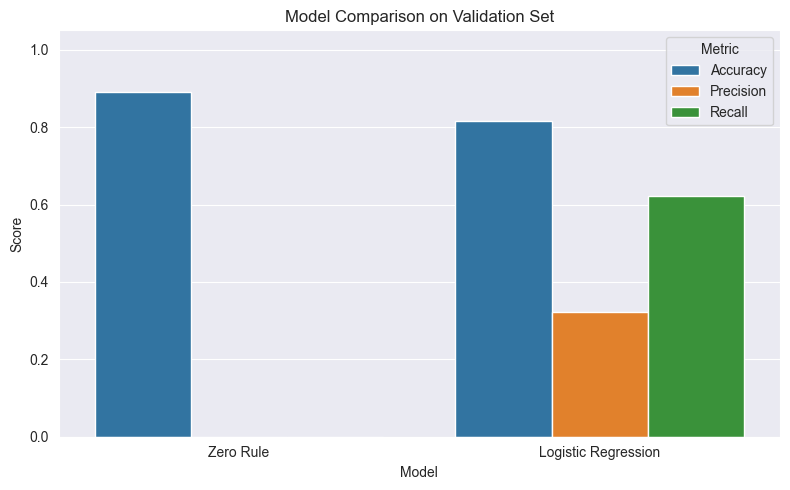

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

# Reshape for plotting
comparison_melted = comparison.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(8,5))
sns.barplot(
    data=comparison_melted,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.ylim(0, 1.05)
plt.title("Model Comparison on Validation Set")
plt.ylabel("Score")
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

When compared to the Zero Rule baseline, which achieved a higher accuracy of 0.89 but zero precision and recall, it is clear that accuracy alone is misleading in this imbalanced setting. The Zero Rule simply predicts the majority class (“no”) and completely fails to identify any subscribers. In contrast, the Logistic Regression model sacrifices some overall accuracy in order to meaningfully detect the minority class (“yes”).